## Unsupervised Learning
#### by **Ivan Alducin**
<p><img src="https://cdn.gritglobal.io/uploads/too-broad-customer-segmentation.jpg" width="1000"/></p>

## Segmentacion de Clientes
<p>En esté capitulo nos vamos a enfocar en entender y trabajar un caso de uso para segmentación de clientes, pero antes de eso aquí una pequeña lista de más aplicaciones que se pueden trabajar con los datos recopliados de mis clientes

- Estadística Descriptiva
- Segmentación de Clientes
- Predicción de Abandono
- Valor del Cliente a traves del tiempo (CTLV)

La segmentación la vamos a hacer con base en una metodolgía llamada <b>RFM</b>

</p>

In [ ]:
# Importa Pandas, Numpy, Seaborn y Matplotlib
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

# Importa el archivo "Online Retail.csv"
df = pd.read_csv("M30 Online Retail.csv", encoding="unicode_escape")
df

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2019 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2019 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/2020 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2020 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2020 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2020 12:50,4.15,12680.0,France


In [2]:
# Análisis Exploratorio
import sweetviz as sv
my_report = sv.analyze(df) #pairwise_analysis="off"
my_report.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Recency
<p>Indicador que nos dice que tan reciente es la compra de un cliente</p>

In [153]:
# Obtener los clientes unicos
customer = df.groupby('CUSTOMER_ID')

In [154]:
# Obtener la última fecha de compra por cliente
max_purchase = customer["INVOICE_DATE"].max()
max_purchase

CUSTOMER_ID
12346.0    18/01/2020 10:17
12347.0    31/10/2020 12:25
12348.0    25/09/2020 13:13
12349.0    21/11/2020 09:51
12350.0    02/02/2020 16:01
                 ...       
18280.0    07/03/2020 09:52
18281.0    12/06/2020 10:53
18282.0    09/08/2020 15:10
18283.0    30/11/2020 12:59
18287.0    28/10/2020 09:29
Name: INVOICE_DATE, Length: 4372, dtype: object

In [155]:
from datetime import datetime

# Formato de la columna de fechas
formato_entrada = "%d/%m/%Y %H:%M"

# Obtener la fecha y hora actual
fecha_actual = datetime.now()

# Calcular la diferencia para cada fecha
diferencias = []
for fecha_str in max_purchase:
    # Convertir la fecha string a objeto datetime
    fecha_obj = datetime.strptime(fecha_str, formato_entrada)
    # Calcular la diferencia
    diferencia = fecha_actual - fecha_obj
    # Guardar la diferencia
    diferencias.append(diferencia.days)

In [156]:
# Vamos a calcular nuestra metrica de Recency, esto lo haremos restando los días de la última fecha de compra a cada observacón
max_purchase = pd.DataFrame(max_purchase)
max_purchase['RECENCY'] = diferencias
max_purchase

,INVOICE_DATE,RECENCY
CUSTOMER_ID,,
12346.0,18/01/2020 10:17,1997
12347.0,31/10/2020 12:25,1710
12348.0,25/09/2020 13:13,1746
12349.0,21/11/2020 09:51,1689
12350.0,02/02/2020 16:01,1982
...,...,...
18280.0,07/03/2020 09:52,1948
18281.0,12/06/2020 10:53,1851
18282.0,09/08/2020 15:10,1793


In [157]:
# Unir el DataFrame de clientes únicos con el que acabamos de crear de la última fecha de compra
max_purchase.insert(0, "CUSTOMER_ID", max_purchase.index)
max_purchase = max_purchase.reset_index(drop=True)
max_purchase

,CUSTOMER_ID,INVOICE_DATE,RECENCY
0,12346.0,18/01/2020 10:17,1997
1,12347.0,31/10/2020 12:25,1710
2,12348.0,25/09/2020 13:13,1746
3,12349.0,21/11/2020 09:51,1689
4,12350.0,02/02/2020 16:01,1982
...,...,...,...
4367,18280.0,07/03/2020 09:52,1948
4368,18281.0,12/06/2020 10:53,1851
4369,18282.0,09/08/2020 15:10,1793
4370,18283.0,30/11/2020 12:59,1680


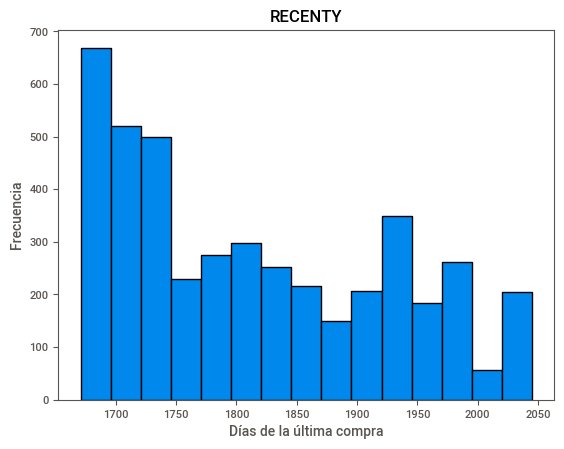

<Figure size 640x480 with 0 Axes>

In [158]:
# Grafica un histograma de Recency
plt.hist(max_purchase["RECENCY"], bins = 15, ec="black")
plt.xlabel("Días de la última compra")
plt.ylabel("Frecuencia")
plt.title("RECENTY")
plt.show()
plt.clf()

In [159]:
# Imprime la Estadística de Resumen para Recency
print(max_purchase["RECENCY"].describe())

count    4372.000000
mean     1815.316560
std       109.483996
min      1671.000000
25%      1716.000000
50%      1792.500000
75%      1912.000000
max      2045.000000
Name: RECENCY, dtype: float64


## Frequency
<p>Frecuencia con la que un cliente compra uno o más productos</p>

In [160]:
# Obtener el número de compras por cliente
frequency = df["CUSTOMER_ID"].value_counts()
frequency = pd.DataFrame(frequency)
frequency = frequency.reset_index()
frequency

,CUSTOMER_ID,count
0,17841.0,7983
1,14911.0,5903
2,14096.0,5128
3,12748.0,4642
4,14606.0,2782
...,...,...
4367,15070.0,1
4368,15753.0,1
4369,17065.0,1
4370,16881.0,1


In [161]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer = pd.merge(max_purchase, frequency, on="CUSTOMER_ID")
customer = customer.rename(columns={'count': 'PURCHASES_QTY'})
customer

,CUSTOMER_ID,INVOICE_DATE,RECENCY,PURCHASES_QTY
0,12346.0,18/01/2020 10:17,1997,2
1,12347.0,31/10/2020 12:25,1710,182
2,12348.0,25/09/2020 13:13,1746,31
3,12349.0,21/11/2020 09:51,1689,73
4,12350.0,02/02/2020 16:01,1982,17
...,...,...,...,...
4367,18280.0,07/03/2020 09:52,1948,10
4368,18281.0,12/06/2020 10:53,1851,7
4369,18282.0,09/08/2020 15:10,1793,13
4370,18283.0,30/11/2020 12:59,1680,756


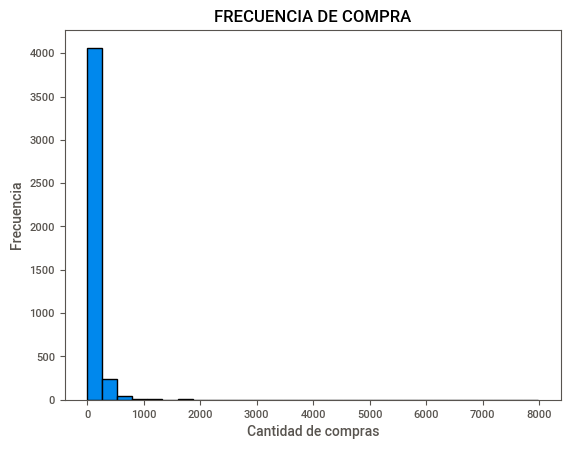

In [162]:
# Grafica un histograma de Frequency
plt.hist(customer["PURCHASES_QTY"], bins = 30, ec="black")
plt.xlabel("Cantidad de compras")
plt.ylabel("Frecuencia")
plt.title("FRECUENCIA DE COMPRA")
plt.show()

In [163]:
# Imprime la Estadística de Resumen para Frequency
print(customer["PURCHASES_QTY"].describe())

count    4372.000000
mean       93.053294
std       232.471608
min         1.000000
25%        17.000000
50%        42.000000
75%       102.000000
max      7983.000000
Name: PURCHASES_QTY, dtype: float64


## Monetary
<p>Valor del monto total que ha gastado un cliente en la compra de mis productos</p>

In [164]:
# Calcular el monto total por cada compra
df['MONETARY'] = df["QUANTITY"]*df["UNIT_PRICE"]

# Obtener el valor monetario de compra por cliente
monetary = df.groupby('CUSTOMER_ID')["MONETARY"].sum()
print(monetary)

CUSTOMER_ID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     176.60
18283.0    2094.88
18287.0    1837.28
Name: MONETARY, Length: 4372, dtype: float64


In [165]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
monetary = pd.DataFrame(monetary)
monetary.insert(0, "CUSTOMER_ID", monetary.index)
monetary = monetary.reset_index(drop=True)
customer = pd.merge(customer, monetary, on = "CUSTOMER_ID")
customer

,CUSTOMER_ID,INVOICE_DATE,RECENCY,PURCHASES_QTY,MONETARY
0,12346.0,18/01/2020 10:17,1997,2,0.00
1,12347.0,31/10/2020 12:25,1710,182,4310.00
2,12348.0,25/09/2020 13:13,1746,31,1797.24
3,12349.0,21/11/2020 09:51,1689,73,1757.55
4,12350.0,02/02/2020 16:01,1982,17,334.40
...,...,...,...,...,...
4367,18280.0,07/03/2020 09:52,1948,10,180.60
4368,18281.0,12/06/2020 10:53,1851,7,80.82
4369,18282.0,09/08/2020 15:10,1793,13,176.60
4370,18283.0,30/11/2020 12:59,1680,756,2094.88


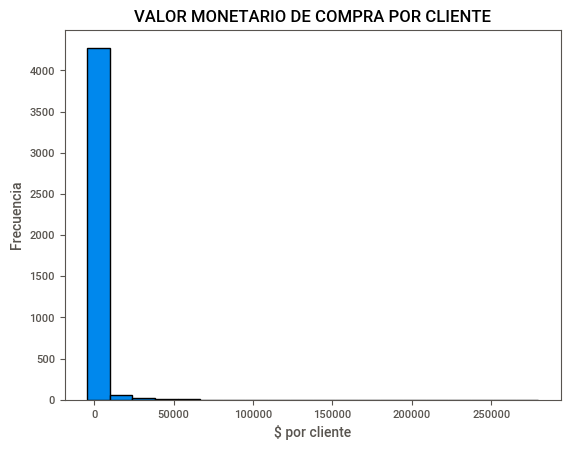

In [166]:
# Grafica un histograma de Monetary
plt.hist(customer["MONETARY"], bins = 20, ec="black")
plt.xlabel("$ por cliente")
plt.ylabel("Frecuencia")
plt.title("VALOR MONETARIO DE COMPRA POR CLIENTE")
plt.show()

In [167]:
# Imprime la Estadística de Resumen para Monetary
print(customer["MONETARY"].describe())

count      4372.000000
mean       1898.459701
std        8219.345141
min       -4287.630000
25%         293.362500
50%         648.075000
75%        1611.725000
max      279489.020000
Name: MONETARY, dtype: float64


## Algoritmo k-Means
<p>Ya creamos nuestros indicadores principales de la metodología RFM. es hora de hacer <i>Machine Learning</i>. Para ello utilizaremos un algoritmo no supervisado llamado <b>k-Means</b></p>
<p><img src="https://miro.medium.com/max/818/1*fG8u8nV7qR91wDyFDEEV-g.png" width="250"/></p>

In [168]:
# Funcion para ordenar los clusters
def order_cluster(cluster_field_name, target_field_name, df, ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

## Elbow Method
<p>¿Cual es mi número óptimo de clusters? Vamos a contruir una <i>gráfica de codo</i> para averiguarlo</p>

In [169]:
# Importa la librería de kMeans
from sklearn.cluster import KMeans

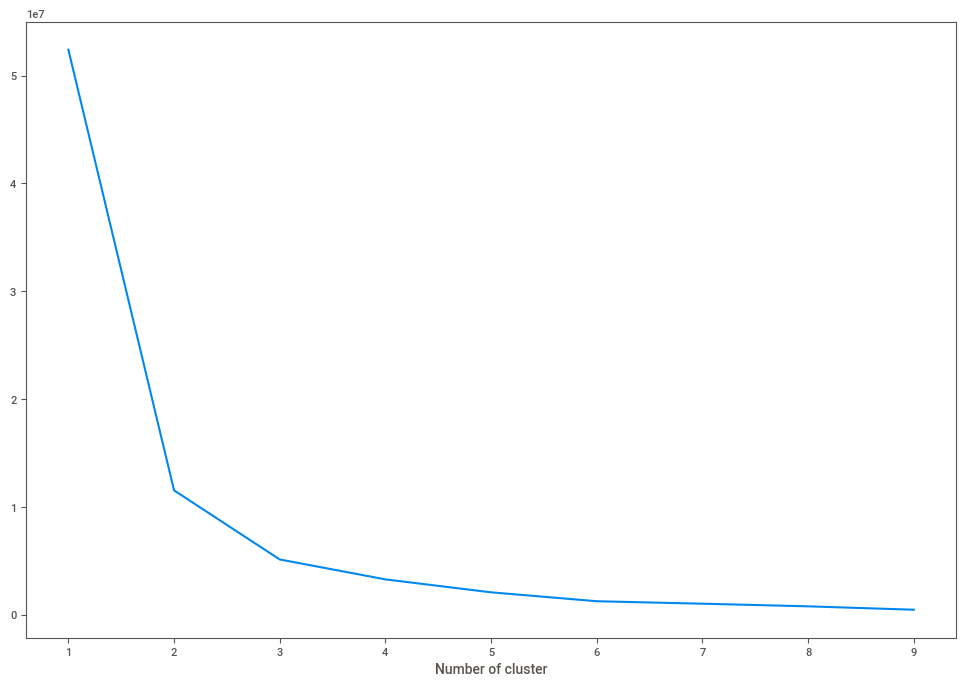

In [171]:
# Configuración inicial - Vamos a tomar como referencia el indicador de Recency
sse={}

for k in range(1, 10):
    # Instancia el algoritmo de k-means iterando sobre k
    kmeans = KMeans(n_clusters = k, init="k-means++", random_state=2)
    # Entrena el algoritmo
    kmeans.fit(customer[["RECENCY"]])
    # Adunta la inercia o variación al arreglo sse
    sse[k] = kmeans.inertia_
    
# Grafico de codo (Elbow)
plt.figure(figsize=(12,8))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()

In [172]:
# Instanciar el algoritmo con 4 clusters para Recency 
kmeans = KMeans(n_clusters = 4, init="k-means++", random_state=2)
# Entrenar el algoritmo
kmeans.fit(customer[["RECENCY"]])
# Obtener las predicciones
customer['RECENCY_CLUSTER'] = kmeans.fit_predict(customer[["RECENCY"]])

# Ordenar los clusters
customer = order_cluster('RECENCY_CLUSTER', 'RECENCY', customer, False)

# Estadística Descriptiva del cluster creado
customer.groupby("RECENCY_CLUSTER")["RECENCY"].describe()

,count,mean,std,min,25%,50%,75%,max
RECENCY_CLUSTER,,,,,,,,
0,711.0,1993.791842,29.790848,1945.0,1968.5,1988.0,2026.0,2045.0
1,1007.0,1894.241311,31.709328,1839.0,1868.0,1897.0,1925.0,1944.0
2,1215.0,1780.455967,31.557607,1741.0,1748.0,1777.0,1806.0,1837.0
3,1439.0,1701.336345,17.721874,1671.0,1685.0,1700.0,1715.0,1739.0


In [173]:
# Instanciar el algoritmo con 4 clusters para Frequency 
kmeans = KMeans(n_clusters = 4, init="k-means++", random_state=2)
# Entrenar el algoritmo
kmeans.fit(customer[["PURCHASES_QTY"]])
# Obtener las predicciones
customer['FREQUENCY_CLUSTER'] = kmeans.fit_predict(customer[["PURCHASES_QTY"]])

# Ordenar los clusters
customer = order_cluster('FREQUENCY_CLUSTER', 'PURCHASES_QTY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby("FREQUENCY_CLUSTER")["PURCHASES_QTY"].describe()

,count,mean,std,min,25%,50%,75%,max
FREQUENCY_CLUSTER,,,,,,,,
0,3862.0,49.753755,44.812998,1.0,15.0,34.0,73.0,189.0
1,482.0,329.107884,132.670589,190.0,228.0,286.0,393.5,803.0
2,24.0,1349.750000,508.637759,872.0,1003.5,1156.0,1541.0,2782.0
3,4.0,5914.000000,1473.845537,4642.0,5006.5,5515.5,6423.0,7983.0


In [174]:
# Instanciar el algoritmo con 4 clusters para Monetary 
kmeans = KMeans(n_clusters = 4, init="k-means++", random_state=2)
# Entrenar el algoritmo
kmeans.fit(customer[["MONETARY"]])
# Obtener las predicciones
customer['MONETARY_CLUSTER'] = kmeans.fit_predict(customer[["MONETARY"]])

# Ordenar los clusters ¿Como tienes que ordenar el cluster?
customer = order_cluster('MONETARY_CLUSTER', 'MONETARY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby("MONETARY_CLUSTER")["MONETARY"].describe()

,count,mean,std,min,25%,50%,75%,max
MONETARY_CLUSTER,,,,,,,,
0,4332.0,1359.641714,2045.005429,-4287.63,291.0375,640.795,1553.8650,18793.41
1,33.0,37238.807273,14403.896372,19786.44,26763.3400,33350.760,50992.6100,65892.08
2,5.0,129057.952000,36658.292209,88125.38,113384.1400,123725.450,132572.6200,187482.17
3,2.0,267963.755000,16299.186073,256438.49,262201.1225,267963.755,273726.3875,279489.02


## Score de Segmentación
<p>El algoritmo de k-means nos da una segmentación generalizada, pero podemos personalizarla aún más creando una métrica que asigne una calificación al valor del cluster. Esto es lo que vamos a hacer!!</p>

In [193]:
# Vamos a crear nuestro score sumando el valor de cada uno de los clusters
customer['SCORE'] = customer["RECENCY_CLUSTER"] + customer["FREQUENCY_CLUSTER"] + customer["MONETARY_CLUSTER"]

# Obtener el promedio para cada una de las métricas de las calificaciones creadas (Score)
customer[["RECENCY_CLUSTER", "FREQUENCY_CLUSTER", "MONETARY_CLUSTER"]].mean()

RECENCY_CLUSTER      1.773559
FREQUENCY_CLUSTER    0.123971
MONETARY_CLUSTER     0.011208
dtype: float64

In [195]:
# Crea una funcion que asigne lo siguiente: 
# Si score <= 1 entonces 'Low-Value', si score >1 y <=4 entonces 'Average', si score >4 y <=6 entonces 'Potential', por último si score >6 entonces 'High-Value'
def segment(score):
    aux = []
    for i in score:
        if i <= 1:
            aux.append("Low-Value")
        elif i > 1 and i <= 4:
            aux.append("Average")
        elif i > 4 and i <= 6:
            aux.append("Potential")
        else:
            aux.append("High-Value")
    return aux


# Crear una columna aplicando esta función al campo 'SCORE'
customer['SEGMENT'] = segment(customer["SCORE"])

In [196]:
# Vamos a dar un vistazo a la tabla final
customer.head()

,CUSTOMER_ID,INVOICE_DATE,RECENCY,PURCHASES_QTY,MONETARY,RECENCY_CLUSTER,FREQUENCY_CLUSTER,MONETARY_CLUSTER,SCORE,SEGMENT
0,12346.0,18/01/2020 10:17,1997,2,0.00,0,0,0,0,Low-Value
1,12350.0,02/02/2020 16:01,1982,17,334.40,0,0,0,0,Low-Value
2,12356.0,18/01/2020 09:50,1997,59,2811.43,0,0,0,0,Low-Value
3,12361.0,25/02/2020 13:51,1959,10,189.90,0,0,0,0,Low-Value
4,12365.0,21/02/2020 14:04,1963,23,320.69,0,0,0,0,Low-Value


In [197]:
# Imprime la proporción o el total de clientes por segmento
customer.groupby("SEGMENT").count()

,CUSTOMER_ID,INVOICE_DATE,RECENCY,PURCHASES_QTY,MONETARY,RECENCY_CLUSTER,FREQUENCY_CLUSTER,MONETARY_CLUSTER,SCORE
SEGMENT,,,,,,,,,
Average,2741,2741,2741,2741,2741,2741,2741,2741,2741
High-Value,5,5,5,5,5,5,5,5,5
Low-Value,1608,1608,1608,1608,1608,1608,1608,1608,1608
Potential,18,18,18,18,18,18,18,18,18


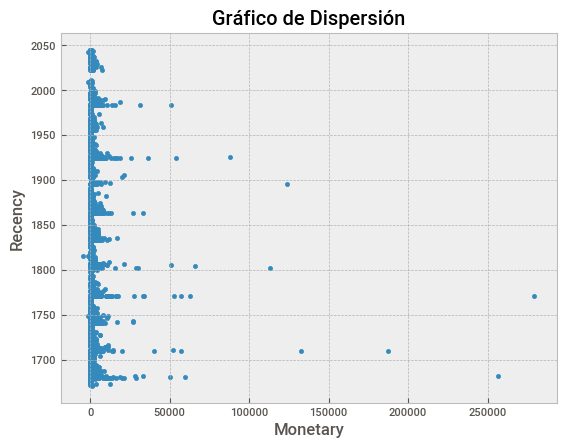

In [198]:
# Define un estilo 'bmh'
plt.style.use("bmh")

# Filtra los valores para RECENCY < 4000
customer_filter = customer[customer["RECENCY"] < 4000]

# Crea un grafico de dispersion de 'MONETARY' VS 'RECENCY' por Segmento
plt.scatter(customer_filter["MONETARY"], customer_filter["RECENCY"])
plt.title('Gráfico de Dispersión')
plt.xlabel('Monetary')
plt.ylabel('Recency')
plt.show()


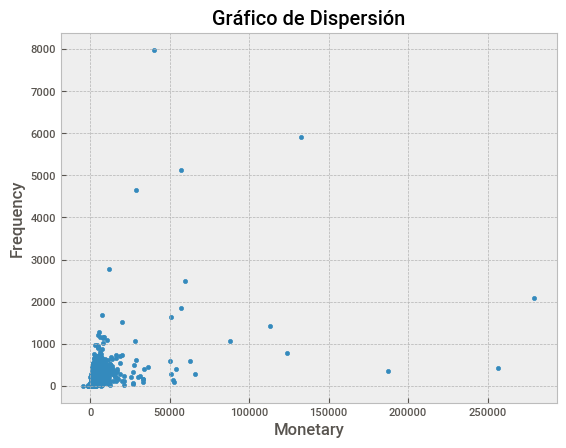

In [202]:
# Crea un grafico de dispersion de 'MONETARY' VS 'FREQUENCY' por Segmento
plt.scatter(customer_filter["MONETARY"], customer_filter["PURCHASES_QTY"])
plt.title('Gráfico de Dispersión')
plt.xlabel('Monetary')
plt.ylabel('Frequency')
plt.show()